In [3]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib_inline import backend_inline
import torch.nn as nn
backend_inline.set_matplotlib_formats('svg')
# 开启 CuDNN 加速，提高 GPU 训练效率
torch.backends.cudnn.benchmark = True

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [5]:
# ===================== 1. 数据准备 =====================
# 定义数据预处理：
transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5), # 随机水平翻转
    transforms.RandomCrop(32, padding=1),   # 随机裁剪
    transforms.ColorJitter(brightness=0.1,  # 颜色抖动
                           contrast=0.1,
                           saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465],
                         std=[0.2023, 0.1994, 0.2010])#(均值)，(标准差)
])
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465],
                         std=[0.2023, 0.1994, 0.2010])#(均值)，(标准差)
])
# 加载 CIFAR10 训练集，指定本地路径
train_dataset = datasets.CIFAR10(root='C:/Jupyter(Anaconda)/data/', train=True, transform=transform, download=False)
# 加载 CIFAR10 测试集（用于验证模型）
test_dataset = datasets.CIFAR10(root='C:/Jupyter(Anaconda)/data/', train=False, transform=transform_test, download=False)

#创建数据集的 DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=256,
    shuffle=True,
    drop_last=True,  # 丢弃最后不足 batch_size 的样本
    num_workers=2,
    pin_memory=(device.type == "cuda"),
    persistent_workers=True,
    # 新增：预取因子，每个worker预取2批数据
    prefetch_factor=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1024,
    shuffle=False,
    pin_memory=(device.type == "cuda")
)

In [6]:
class InceptionModule(nn.Module):
    def __init__(self, in_channels, out_1x1, out_3x3_reduce, out_3x3, out_5x5_reduce, out_5x5, out_pool):
        super(InceptionModule, self).__init__()
        self.activation = nn.LeakyReLU(negative_slope=0.01)
        # 分支1：1x1卷积
        self.branch1 = nn.Sequential(
            nn.Conv2d(in_channels, out_1x1, kernel_size=1),
            nn.BatchNorm2d(out_1x1),#BatchNorm非常关键，从60%提到90%以上
        )
        
        # 分支2：
        self.branch2 = nn.Sequential(
            nn.Conv2d(in_channels, out_3x3_reduce, kernel_size=1),#先1x1降维
            nn.BatchNorm2d(out_3x3_reduce),
            nn.LeakyReLU(inplace=True),
            nn.Conv2d(out_3x3_reduce, out_3x3, kernel_size=3, padding=1),#再3x3卷积
            nn.BatchNorm2d(out_3x3),
        )
        # 分支3：5x5用padding=2保持尺寸）
        self.branch3 = nn.Sequential(
            nn.Conv2d(in_channels, out_5x5_reduce, kernel_size=1),#1x1降维
            nn.BatchNorm2d(out_5x5_reduce),
            nn.LeakyReLU(inplace=True),
            nn.Conv2d(out_5x5_reduce, out_5x5, kernel_size=5, padding=2),#5x5卷积
            nn.BatchNorm2d(out_5x5),
        )
        # 分支4：3x3池化 -> 1x1卷积调整通道
        self.branch4 = nn.Sequential(
            nn.MaxPool2d(kernel_size=3, stride=1, padding=1),
            nn.Conv2d(in_channels, out_pool, kernel_size=1),
            nn.BatchNorm2d(out_pool),
        )
        # 新增残差连接：输入直接加到输出上
        self.out_channels = out_1x1 + out_3x3 + out_5x5 + out_pool
        self.shortcut = nn.Sequential(
            nn.Conv2d(in_channels, self.out_channels, kernel_size=1, stride=1, bias=False),
            nn.BatchNorm2d(self.out_channels)
        )
    def forward(self, x):#更改激活函数位置
        branch_out = torch.cat([self.branch1(x), self.branch2(x), self.branch3(x), self.branch4(x)], dim=1)
        residual = self.shortcut(x)
        out = self.activation(branch_out + residual)
        return out

In [7]:
# ===================== 2. 模型定义 =====================
class LSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super(LSTM, self).__init__()
        # 保存隐藏层大小和层数
        self.num_layers = num_layers
        self.hidden_size = hidden_size
        # 定义 LSTM 层
        self.lstm = torch.nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        # 使用 Sequential 定义分类头
        self.linearclassifier = torch.nn.Sequential(
            torch.nn.Linear(hidden_size, num_classes)
        )

    def forward(self, x):
        # 初始化隐藏状态 h0 和细胞状态 c0
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size, device=device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size, device=device)
        # 将数据送入 LSTM 层
        out, _ = self.lstm(x, (h0, c0))
        # 提取最后一个时间步的输出，送入分类层
        out = self.linearclassifier(out[:, -1, :])
        # 返回分类结果
        return out

In [8]:
class TrainModel(nn.Module):
    def __init__(self):
        # 使用传统风格调用父类初始化
        super(TrainModel, self).__init__()
        # 定义 CNN 部分：处理彩色输入图像
        self.CNN = nn.Sequential(
            # 前置层：简单卷积+池化，处理 3 通道彩色 32x32 输入
            nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, padding=1),
            # 输出图像尺寸：32x32（因为 padding=1），通道数：64
            nn.BatchNorm2d(64),
            nn.LeakyReLU(inplace=True),
            nn.AvgPool2d(kernel_size=2, stride=2),  # 输出图像尺寸：16x16
            # Inception 模块：多尺度特征提取
            InceptionModule(in_channels=64, out_1x1=32, out_3x3_reduce=24, out_3x3=32, out_5x5_reduce=4, out_5x5=8, out_pool=8),
            # 输出通道：32+32+8+8=80，空间尺寸：16x16
        )
        # 定义 LSTM 部分：处理 CNN 提取的特征序列
        # 注意：input_size 需要根据特征转换方案调整
        # 方案2使用1280维特征（16*80）
        self.LSTM = LSTM(input_size=1280, hidden_size=128, num_layers=2, num_classes=10)
    
    def forward(self, x):
        # x 的形状：(batch_size, 3, 32, 32)
        # CNN 处理
        x = self.CNN(x)  # 输出形状：(batch_size, 80, 16, 16)
        
        # 改变形状为 LSTM 输入格式：(batch, seq_len, input_size)
        batch_size, channels, height, width = x.size()
        
        #按列展开，将16列作为序列长度，每列16*80=1280特征
        x = x.permute(0, 3, 1, 2)  # (batch, width=16, channels=80, height=16)
        x = x.reshape(batch_size, width, channels * height)  # (batch, 16, 1280)
        
        # LSTM 处理序列特征
        x = self.LSTM(x)  # 输出形状：(batch_size, 10)
        # 返回分类结果
        return x

In [ ]:
# ===================== 3. 训练配置 =====================
# 实例化 CNN-LSTM 组合模型，CNN 部分提取特征，LSTM 部分处理特征序列
model = TrainModel().to(device)
# 定义损失函数：多分类交叉熵
Loss_fn = torch.nn.CrossEntropyLoss()
# 定义优化器：Adam 算法，学习率使用超参数 lr
optimizer = torch.optim.Adam(model.parameters(), 
                             lr=0.001,
                             weight_decay=1e-4)
scheduler=torch.optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=15,eta_min=1e-5)

In [ ]:
# ===================== 4. 训练与验证循环 =====================
# 用于记录每轮训练的准确率
train_acc_history = []
# 用于记录每轮验证的准确率
val_acc_history = []

# 使用超参数 epochs 定义训练轮数
epochs = 15
for epoch in range(epochs):
    # --- 训练阶段 ---
    model.train()
    # 记录本轮训练正确的样本数
    train_correct, train_total = 0, 0
    for imgs, labels in train_loader:
        # 将彩色图像数据搬运至计算设备
        imgs, labels = imgs.to(device), labels.to(device)
        # 前向传播
        outputs = model(imgs)
        # 计算损失
        loss = Loss_fn(outputs, labels)
        
        # 优化流程：梯度清零、反向传播、权重更新
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # 统计本批次训练正确的样本数
        train_correct += (outputs.argmax(dim=1) == labels).sum().item()
        train_total += imgs.size(0)
    scheduler.step()
    # --- 验证阶段 ---
    model.eval()
    val_correct, val_total = 0, 0
    # 验证时关闭梯度计算
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            # 统计验证集正确数
            val_correct += (outputs.argmax(dim=1) == labels).sum().item()
            val_total += imgs.size(0)
            
    # 计算本轮准确率
    train_acc = train_correct / train_total
    val_acc = val_correct / val_total
    train_acc_history.append(train_acc)
    val_acc_history.append(val_acc)
    
    # 打印实时进度
    print(f'Epoch [{epoch+1}/{epochs}] - Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}')

Epoch [1/6] - Train Acc: 0.4339, Val Acc: 0.5254
Epoch [2/6] - Train Acc: 0.5465, Val Acc: 0.5530
Epoch [3/6] - Train Acc: 0.6044, Val Acc: 0.6250
Epoch [4/6] - Train Acc: 0.6518, Val Acc: 0.6571
Epoch [5/6] - Train Acc: 0.6839, Val Acc: 0.6802
Epoch [6/6] - Train Acc: 0.7124, Val Acc: 0.6890


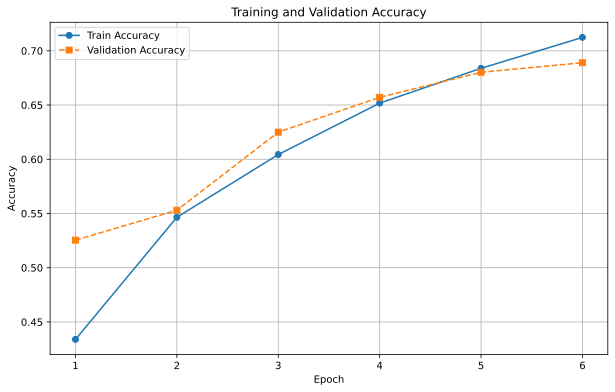

In [11]:
# ===================== 5. 可视化训练结果 =====================
# 创建绘图窗口
plt.figure(figsize=(10, 6))
# 绘制准确率曲线，横坐标根据 epochs 动态生成
plt.plot(range(1, epochs + 1), train_acc_history, label='Train Accuracy', marker='o')
plt.plot(range(1, epochs + 1), val_acc_history, label='Validation Accuracy', marker='s', linestyle='--')
# 图表修饰
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()